In [2]:
import pandas as pd
import numpy as np
import pydotplus  # Check the references if you need help to install this module.
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, export_graphviz  # References: download link and instructions to install Graphviz.
from IPython.display import Image  # To plot decision tree.
from six import StringIO
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import RandomForestRegressor

%matplotlib inline

In [4]:
df = pd.read_csv('Carseats.csv')

In [8]:
df.head()


,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [9]:
df = pd.get_dummies(df)


In [11]:
df.head()


,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education,ShelveLoc_Bad,ShelveLoc_Good,ShelveLoc_Medium,Urban_No,Urban_Yes,US_No,US_Yes
0,9.50,138,73,11,276,120,42,17,1,0,0,0,1,0,1
1,11.22,111,48,16,260,83,65,10,0,1,0,0,1,0,1
2,10.06,113,35,10,269,80,59,12,0,0,1,0,1,0,1
3,7.40,117,100,4,466,97,55,14,0,0,1,0,1,0,1
4,4.15,141,64,3,340,128,38,13,1,0,0,0,1,1,0


In [13]:
def print_tree(estimator, features, class_names=None, filled=True):
    tree = estimator
    names = features
    color = filled
    classn = class_names

    dot_data = StringIO()
    export_graphviz(estimator, out_file=dot_data, feature_names=features, class_names=classn, filled=filled)
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    return(graph)


In [20]:
# Split data into training and test set
X = df.loc[:, df.columns[1:]]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=1)


In [21]:
# Fit regression tree
rgr = DecisionTreeRegressor(max_depth=3)  # We could have chosen another max_depth value.
rgr.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3)

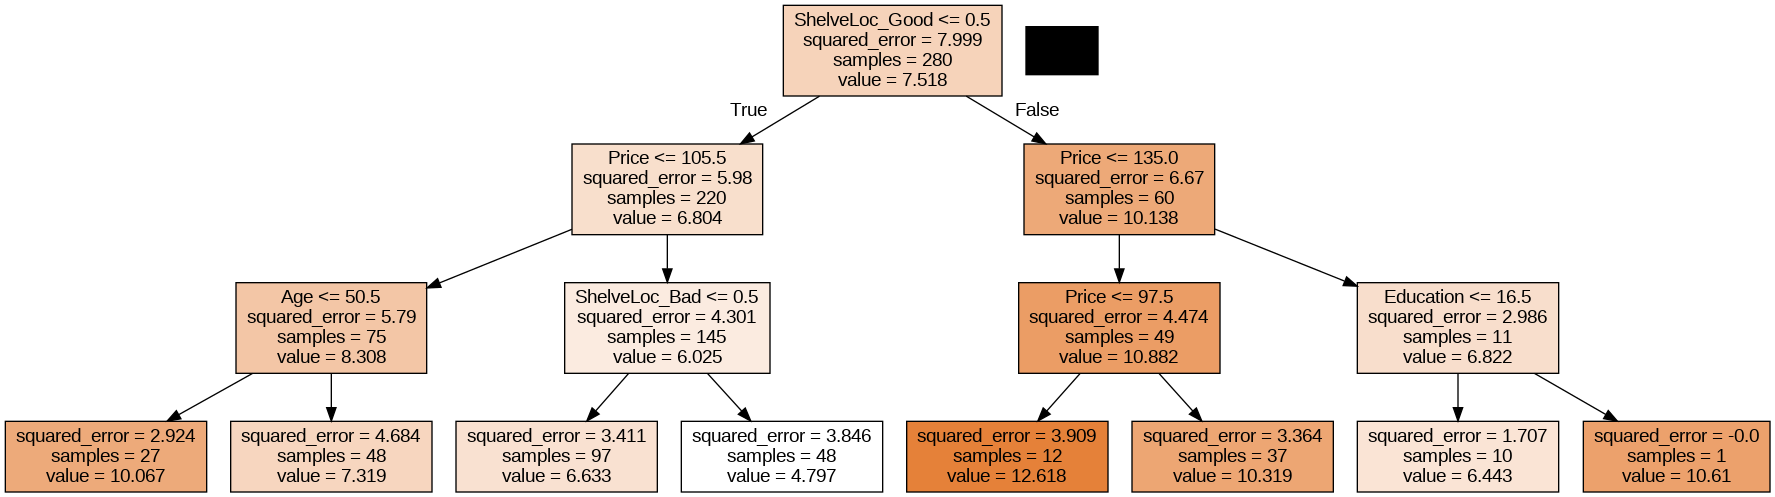

In [22]:
# Plot the tree
graph = print_tree(rgr, features=list(X_train.columns.values))
Image(graph.create_png())

In [23]:
# Test MSE
print('Test MSE: ', mean_squared_error(y_test, rgr.predict(X_test)))


Test MSE:  4.725166009939633


In [24]:
# Build a regressor
rgr = DecisionTreeRegressor(random_state=1)

In [25]:
# Grid of parameters to hypertune
param_grid = {'max_depth':[1,2,3,4,5,6,7,8,9,10]}

In [26]:
# Run grid search
grid_search = GridSearchCV(rgr,
                           param_grid=param_grid,
                           cv=5)
grid_search.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=1),
             param_grid={'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]})

In [31]:
estimator = DecisionTreeRegressor(
    criterion='mse',
    max_depth=None,
    max_features=None,
    max_leaf_nodes=None,
    min_impurity_decrease=1e-07,
    min_samples_leaf=1,
    min_samples_split=2,
    min_weight_fraction_leaf=0.0,
    random_state=1,
    splitter='best'
)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=estimator,
    param_grid={'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]},
    cv=5,
    error_score='raise',
    n_jobs=1,
    return_train_score=True,
    verbose=0
)

In [32]:
grid_search.best_estimator_


AttributeError: ignored

In [37]:
import numpy as np
import pandas as pd
import patsy as pt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from IPython.display import HTML
from ipywidgets import interact
import ipywidgets as widgets
import copy
import warnings
warnings.filterwarnings('ignore')

from sklearn import tree
import graphviz
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn import datasets
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import Lasso
import statsmodels.api as sm
from sklearn.neighbors import KNeighborsClassifier

In [36]:
carseats_df = pd.read_csv('Carseats.csv')

# Check for missing values
assert carseats_df.isnull().sum().sum() == 0
# Drop unused index
#carseats_df = carseats_df.drop('Unnamed: 0', axis=1)

# Create index for training set
np.random.seed(1)
train = np.random.random(len(carseats_df)) > 0.5

display(carseats_df.head())

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [38]:
# Use all features excpet response features
# No intercept

preds = carseats_df.columns.drop(['Sales'])
#preds_scaled = ['standardize({})'.format(p) for p in preds]
f = 'Sales ~ 0 +' + ' + '.join(preds)
y, X = pt.dmatrices(f, carseats_df)
y = y.flatten()

# Fit Sklearn's tree regressor
clf = tree.DecisionTreeRegressor(max_depth=5).fit(X[train], y[train])

# Measure test set MSE
y_hat = clf.predict(X[~train])
mse = metrics.mean_squared_error(y[~train], y_hat)

# Get proportion of correct classifications on test set
print('Test MSE: {}'.format(np.around(mse, 3)))
print('Test RMSE: {}'.format(np.around(np.sqrt(mse), 3)))

Test MSE: 5.09
Test RMSE: 2.256


2.2252623573730106


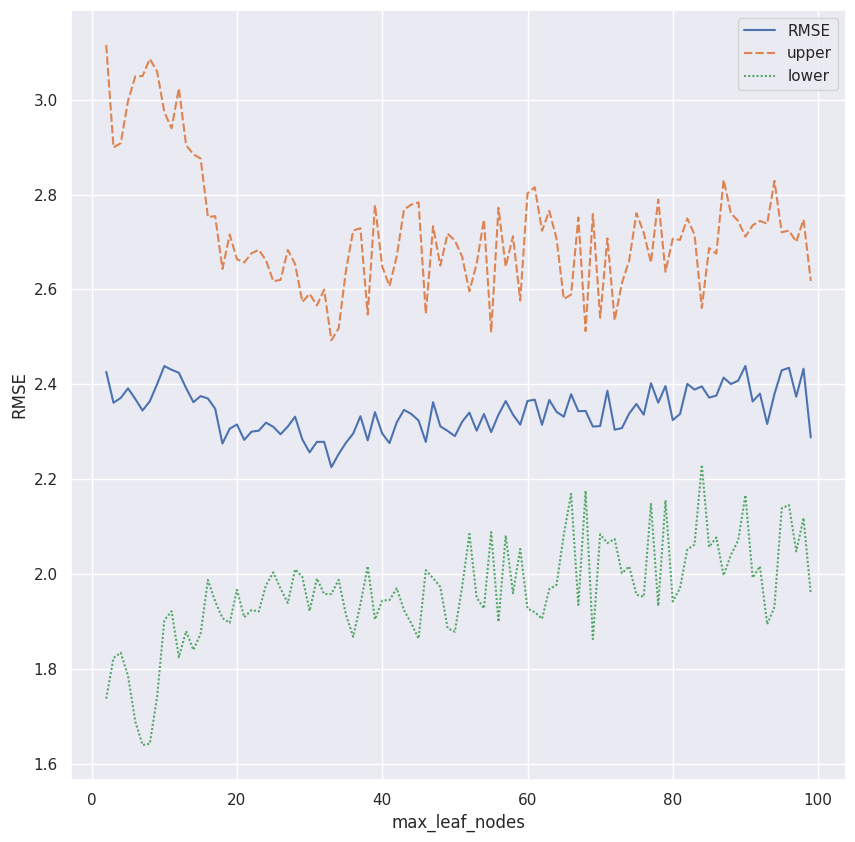

,RMSE,upper,lower
max_leaf_nodes,,,
33.0,2.225262,2.492716,1.957808


Test MSE : 4.524
Test RMSE: 2.127


In [55]:
# How about using CV to compare trees with different number of leaf nodes
# as defined by the max_leaf_nodes parameter?

cv_folds = 10
tuning_param = 'max_leaf_nodes'
columns=[tuning_param, 'RMSE', 'upper', 'lower']

results = []
rmse_array = []
for m in np.arange(2, 100):
    regr = tree.DecisionTreeRegressor(max_leaf_nodes=m)
    scores = cross_val_score(regr, X[train], y[train], cv=cv_folds, scoring='neg_mean_squared_error')
    rmses = np.sqrt(np.absolute(scores))
    rmse = np.mean(rmses)
    conf_int = np.std(rmses) *2
    rmse_array.append(rmse)
    results += [[m, rmse, rmse+conf_int, rmse-conf_int]]

# Plot classification accuracy for each max_depth cv result
plot_df = pd.DataFrame(np.asarray(results), columns=columns).set_index(tuning_param)
plt.figure(figsize=(10,10))
sns.lineplot(data=plot_df)
plt.ylabel('RMSE')
plt.show();

# Show chosen model
chosen = plot_df[plot_df['RMSE'] == plot_df['RMSE'].min()]
display(chosen)

# Use chosen model for test prediction
regr  = tree.DecisionTreeRegressor(max_leaf_nodes=int(chosen.index[0])).fit(X[train], y[train])
y_hat = regr.predict(X[~train])
mse = metrics.mean_squared_error(y[~train], y_hat)

# Get proportion of correct classifications on test set
print('Test MSE : {}'.format(np.around(mse, 3)))
print('Test RMSE: {}'.format(np.around(np.sqrt(mse), 3)))

Test MSE : 2.611
Test RMSE: 1.616


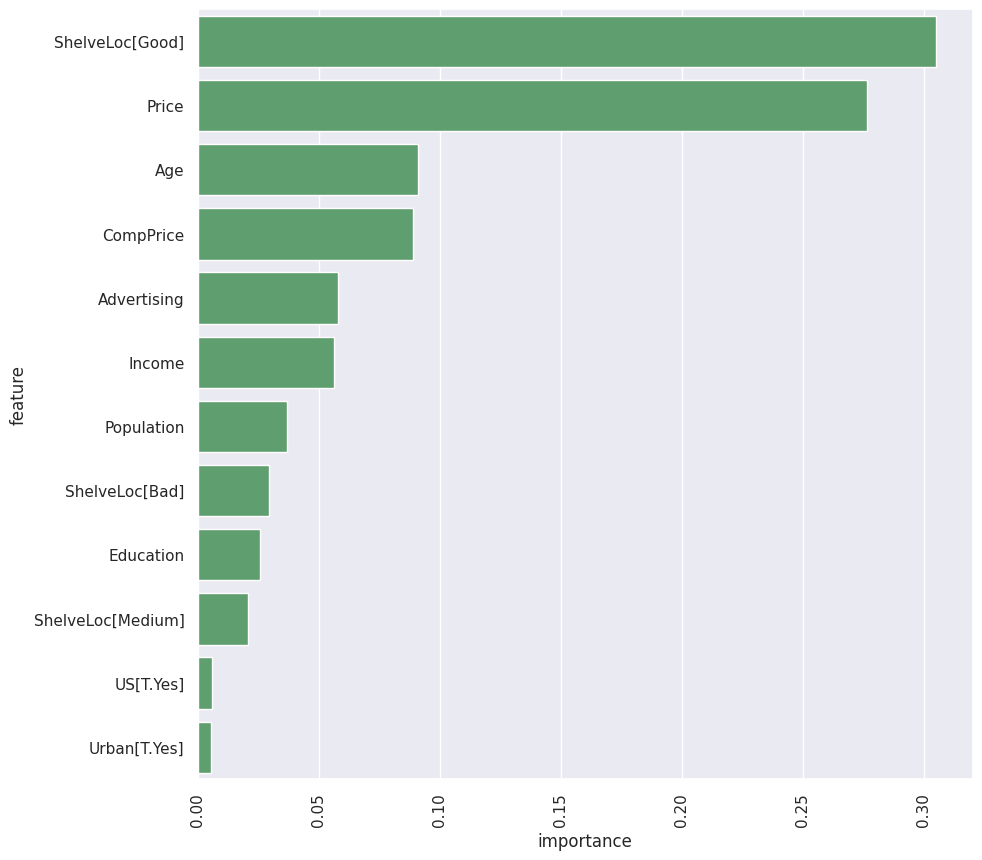

In [48]:
# Plot feature by importance in this model
plot_df = pd.DataFrame({'feature': X.design_info.column_names, 'importance': regr.feature_importances_})

plt.figure(figsize=(10,10))
sns.barplot(x='importance', y='feature', data=plot_df.sort_values('importance', ascending=False),
            color='g')
plt.xticks(rotation=90);

In [42]:
# Random Forest with 100 trees and 4 features considered at each split

max_features = 7
tree_count   = 100

regr   = RandomForestRegressor(max_features=max_features, random_state=0, n_estimators=tree_count)
regr.fit(X[train], y[train])
y_hat = regr.predict(X[~train])

mse = metrics.mean_squared_error(y[~train], y_hat)
rmse = np.sqrt(mse)

print('MSE test: {}'.format(np.around(mse, 3)))
print('RMSE test: {}'.format(np.around(rmse, 3)))

MSE test: 2.566
RMSE test: 1.602


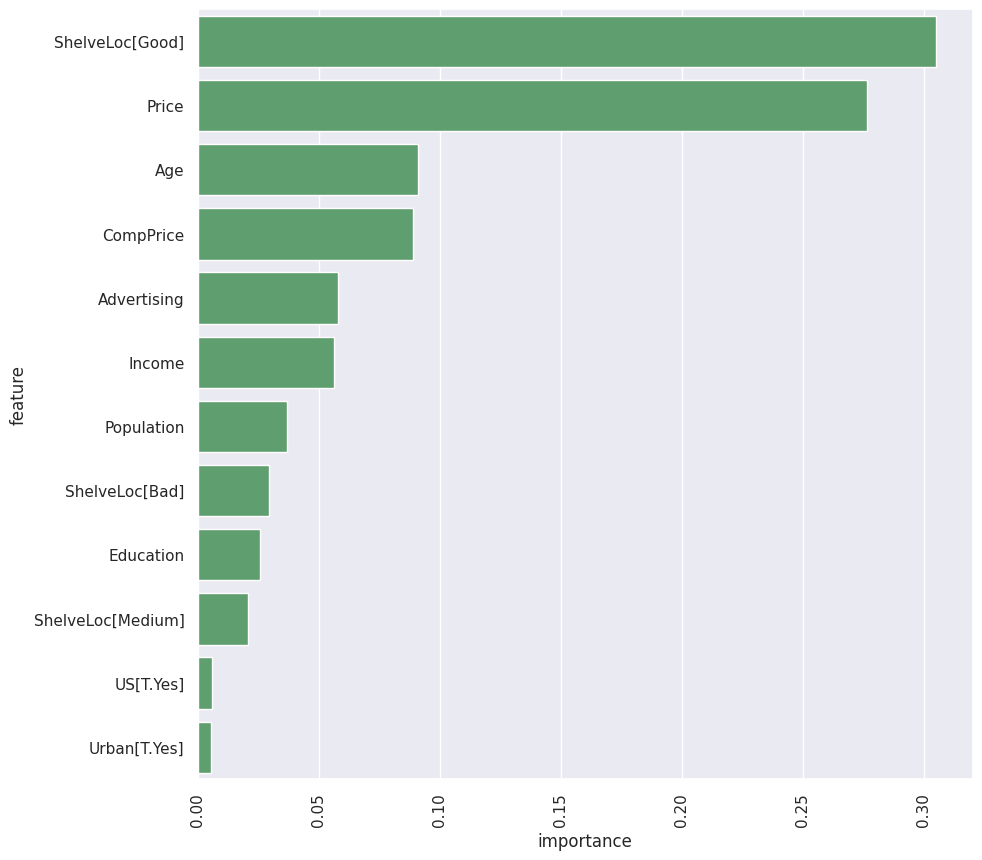

In [45]:
# Plot feature by importance in this model
plot_df = pd.DataFrame({'feature': X.design_info.column_names, 'importance': regr.feature_importances_})

plt.figure(figsize=(10,10))
sns.barplot(x='importance', y='feature', data=plot_df.sort_values('importance', ascending=False),
            color='g')
plt.xticks(rotation=90);

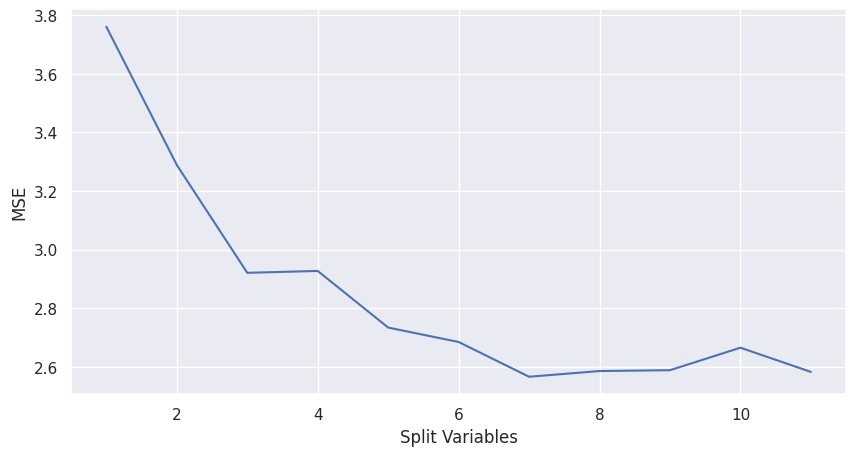

In [44]:
# Describe the effect of m, the number of variables considered at each split, on the error rate obtained.

results = []
for max_features in np.arange(1, X.shape[1]):

    tree_count   = 100

    regr   = RandomForestRegressor(max_features=max_features, random_state=0, n_estimators=tree_count)
    regr.fit(X[train], y[train])
    y_hat = regr.predict(X[~train])

    mse = metrics.mean_squared_error(y[~train], y_hat)
    rmse = np.sqrt(mse)

    results += [[max_features, mse]]

plt.figure(figsize=(10,5))
sns.lineplot(x='Split Variables', y='MSE', data=pd.DataFrame(results, columns=['# of Variables', 'MSE']));

In [57]:
########################## PROBLEM 8.11 #####################################

caravan_df = pd.read_csv('Caravan.csv')

# Patsy feature processing
f = 'C(Purchase) ~ ' + ' + '.join(caravan_df.columns.drop(['Purchase']))
y, X = pt.dmatrices(f, caravan_df)
y = y[:, 1]

# Display processed features
display(pd.DataFrame(X, columns=X.design_info.column_names).head())

# Index for Training set of 1000
np.random.seed(1)
train_sample = np.random.choice(np.arange(len(caravan_df)), size=1000, replace=False)
train = np.asarray([(i in train_sample) for i in caravan_df.index])


,Intercept,MOSTYPE,MAANTHUI,MGEMOMV,MGEMLEEF,MOSHOOFD,MGODRK,MGODPR,MGODOV,MGODGE,...,ALEVEN,APERSONG,AGEZONG,AWAOREG,ABRAND,AZEILPL,APLEZIER,AFIETS,AINBOED,ABYSTAND
0,1.0,33.0,1.0,3.0,2.0,8.0,0.0,5.0,1.0,3.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1.0,37.0,1.0,2.0,2.0,8.0,1.0,4.0,1.0,4.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1.0,37.0,1.0,2.0,2.0,8.0,0.0,4.0,2.0,4.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1.0,9.0,1.0,3.0,3.0,3.0,2.0,3.0,2.0,4.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,1.0,40.0,1.0,4.0,2.0,10.0,1.0,4.0,1.0,4.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


accuracy: 93.26%


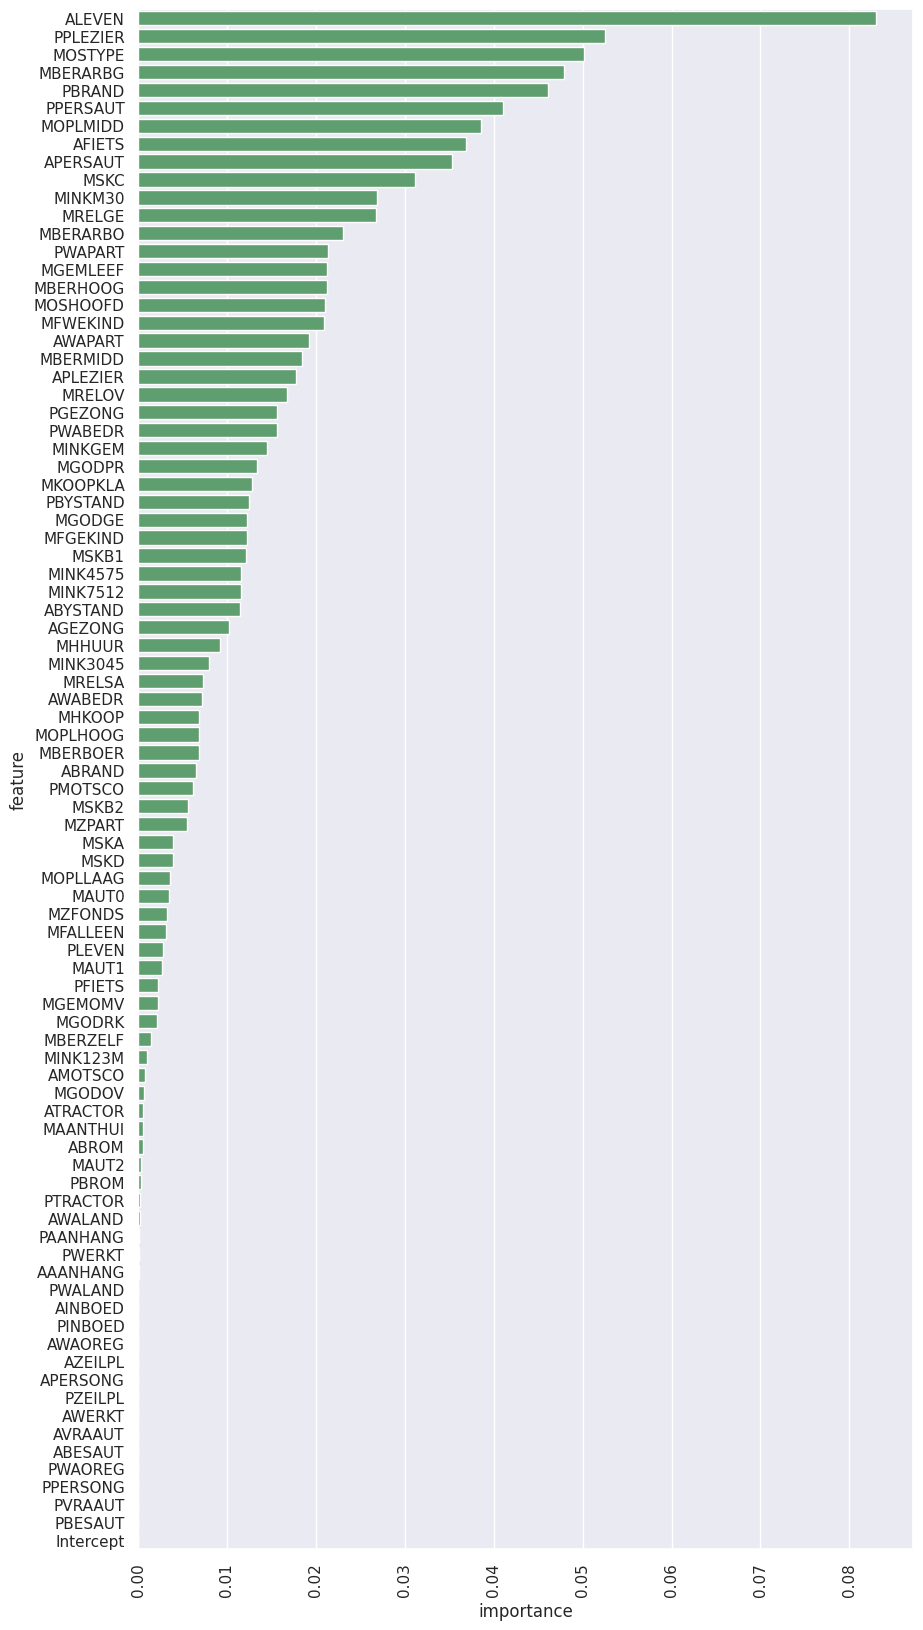

In [59]:
max_features = 'auto'
tree_count   = 1000
learning_rate = 0.01

model = GradientBoostingClassifier(max_features=max_features,
                                       random_state=1,
                                       n_estimators=tree_count,
                                       learning_rate=learning_rate)

model = model.fit(X[train], y[train])
#y_hat_test  = regr.predict(X[~train])

accuracy = model.score(X[~train], y[~train])
print('accuracy: {}%'.format(np.around(accuracy*100, 2)))

# Plot feature by importance in this model

plot_df = pd.DataFrame({'feature': X.design_info.column_names, 'importance': model.feature_importances_})

plt.figure(figsize=(10,20))
sns.barplot(x='importance', y='feature', data=plot_df.sort_values('importance', ascending=False),
            color='g')
plt.xticks(rotation=90);

In [60]:
max_features = 'auto'
tree_count   = 1000
learning_rate = 0.01

model = GradientBoostingClassifier(max_features=max_features,
                                       random_state=1,
                                       n_estimators=tree_count,
                                       learning_rate=learning_rate)

model = model.fit(X[train], y[train])
#y_hat_test  = regr.predict(X[~train])


# Boosting stats
threshold = 0.2
y_hat_proba = model.predict_proba(X[~train])
y_hat = (y_hat_proba[:, 1] > threshold).astype(np.float64)
confusion_mat = confusion_matrix(y[~train], y_hat)

# What fraction of the people predicted to make a purchase do in fact make one?
pos_pred_val = np.around(confusion_mat[:, 1][1] / np.sum(confusion_mat[:, 1]), 5)

display(HTML('<h4>BOOSTING: Confusion matrix</h4>'))
print(confusion_mat)

print('\nPositive Predictive Value: {}'.format(pos_pred_val))

[[4403  122]
 [ 264   33]]

Positive Predictive Value: 0.2129


In [61]:
# KNN

# PREDICT
for K in range(1, 10):
    # model
    model = KNeighborsClassifier(n_neighbors=K).fit(X[train], y[train])
    # Predict
    y_pred = model.predict(X[~train])

    # Confusion table
    display(HTML('<h3>K={}</h3>'.format(K)))
    confusion_mtx = confusion_matrix(y[~train], y_pred)
    print(confusion_mtx)

    ## Classifier stats
    pos_pred_val = np.around(confusion_mtx[:, 1][1] / np.sum(confusion_mtx[:, 1]), 5)
    print('\nPositive Predictive Value: {}'.format(pos_pred_val))

[[4286  239]
 [ 273   24]]

Positive Predictive Value: 0.09125


[[4507   18]
 [ 293    4]]

Positive Predictive Value: 0.18182


[[4470   55]
 [ 288    9]]

Positive Predictive Value: 0.14062


[[4524    1]
 [ 297    0]]

Positive Predictive Value: 0.0


[[4522    3]
 [ 297    0]]

Positive Predictive Value: 0.0


[[4525    0]
 [ 297    0]]

Positive Predictive Value: nan


[[4525    0]
 [ 297    0]]

Positive Predictive Value: nan


[[4525    0]
 [ 297    0]]

Positive Predictive Value: nan


[[4525    0]
 [ 297    0]]

Positive Predictive Value: nan
